## Overview

This notebook implements stochastic logic circuits using the **Bernstein polynomial method**.  
The key idea: a real number $x \in [0,1]$ is represented as a random bit stream where each bit is 1 with probability $x$.  
We design digital circuits (AND gates, MUXes) that compute polynomial functions on these stochastic bit streams.

### Core Building Blocks
| Operation | Circuit | Stochastic Function |
|-----------|---------|---------------------|
| Multiplication | AND gate | $P_{out} = P_A \cdot P_B$ |
| Complement | NOT gate | $P_{out} = 1 - P_{in}$ |
| Scaled addition | MUX | $P_{out} = s \cdot P_A + (1-s) \cdot P_B$ |

> **Key constraint:** We can only implement functions $g: [0,1] \to [0,1]$ (probability in, probability out).

---
## Setup — Import Libraries

In [1]:
from fractions import Fraction
from math import comb, cos as math_cos, pi
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# ── Core Bernstein utilities ──────────────────────────────────────
def power_to_bernstein(a_coeffs, n):
    """Convert power-form coefficients to Bernstein coefficients (exact).
    Formula: b_i = sum_{j=0}^{i} C(i,j)/C(n,j) * a_j"""
    a = [Fraction(ai) for ai in a_coeffs]
    b = []
    for i in range(n + 1):
        bi = Fraction(0)
        for j in range(i + 1):
            bi += Fraction(comb(i, j), comb(n, j)) * a[j]
        b.append(bi)
    return b

def elevate_bernstein(b, n):
    """Elevate Bernstein polynomial from degree n to n+1 (exact, no approximation)."""
    m = n + 1
    new_b = [Fraction(0)] * (m + 1)
    for i in range(m + 1):
        if i == 0:
            new_b[i] = b[0]
        elif i == m:
            new_b[i] = b[n]
        else:
            new_b[i] = Fraction(i, m) * b[i-1] + Fraction(m-i, m) * b[i]
    return new_b

def bernstein_eval(b, n, t):
    """Evaluate Bernstein polynomial at t using exact Fraction arithmetic."""
    t = Fraction(t)
    return sum(b[i] * comb(n,i) * t**i * (1-t)**(n-i) for i in range(n+1))

def circuit_output(b, n, X):
    """Simulate the MUX circuit expected output (exact).
    E[output] = sum_k b_k * C(n,k) * X^k * (1-X)^(n-k)"""
    X = Fraction(X)
    return sum(b[k] * comb(n,k) * X**k * (1-X)**(n-k) for k in range(n+1))

def check_unit_interval(b):
    return all(Fraction(0) <= bi <= Fraction(1) for bi in b)

def print_bern_table(b, n, title):
    print(f'\n  {title}  (degree n={n})')
    print(f'  {"─"*52}')
    print(f'  {"i":>3}  {"b_i (exact)":>16}  {"b_i (float)":>12}  In [0,1]?')
    print(f'  {"─"*52}')
    for i, bi in enumerate(b):
        ok = '✓' if 0 <= bi <= 1 else '✗  ← need elevation'
        print(f'  {i:>3}  {str(bi):>16}  {float(bi):>12.6f}  {ok}')
    print(f'  {"─"*52}')
    print(f'  All ∈ [0,1]: {"✓ YES — no elevation needed" if check_unit_interval(b) else "✗ NO — degree elevation required"}')

print('Libraries loaded successfully ✓')


Libraries loaded successfully ✓


---
## Part (a): Implement $f(x) = x - \dfrac{x^2}{4}$

### Step 1 — Verify the function maps $[0,1] \to [0,1]$

$$f(0) = 0, \quad f(1) = 1 - \frac{1}{4} = \frac{3}{4}, \quad f'(x) = 1 - \frac{x}{2} > 0 \text{ on } [0,1]$$

Since $f$ is monotonically increasing on $[0,1]$ with range $[0, 3/4] \subset [0,1]$ ✓

### Step 2 — Power form coefficients ($n = 2$)

$$f(x) = 0 + 1\cdot x + \left(-\frac{1}{4}\right)x^2 \implies a_0=0,\; a_1=1,\; a_2=-\frac{1}{4}$$

### Step 3 — Convert to Bernstein form

Using the formula $b_i = \displaystyle\sum_{j=0}^{i} \frac{\binom{i}{j}}{\binom{n}{j}} a_j$:

$$b_0 = a_0 = 0$$

$$b_1 = \frac{\binom{1}{0}}{\binom{2}{0}}a_0 + \frac{\binom{1}{1}}{\binom{2}{1}}a_1 = 0 + \frac{1}{2}\cdot 1 = \frac{1}{2}$$

$$b_2 = a_0 + a_1 + a_2 = 0 + 1 - \frac{1}{4} = \frac{3}{4}$$

All coefficients $b_0=0,\; b_1=\tfrac{1}{2},\; b_2=\tfrac{3}{4}$ are in $[0,1]$ → **no degree elevation needed!**

### Step 4 — Bernstein polynomial verification

$$f(x) = 0 \cdot (1-x)^2 + \frac{1}{2}\cdot 2x(1-x) + \frac{3}{4}\cdot x^2 = x - x^2 + \frac{3}{4}x^2 = x - \frac{x^2}{4} \checkmark$$

### Step 5 — Circuit Description

```
  x ──┐
      ├──[2-bit counter "+"]──sel(0/1/2)──┐
  x ──┘  (counts # of 1s among 2 inputs)  │
                                            ▼
      b₀ = 0   ──── port 0 ┐
      b₁ = 1/2 ──── port 1 ├── 3-to-1 MUX ──→ f(x)
      b₂ = 3/4 ──── port 2 ┘
```
- 2 **independent** stochastic streams of probability $x$
- Adder counts number of 1s: sel ∈ {0, 1, 2}
- MUX selects the corresponding Bernstein coefficient $b_k$


In [2]:
# ── Part (a): f(x) = x - x²/4 ─────────────────────────────────
print('='*55)
print('  Part (a): f(x) = x - x²/4')
print('='*55)

n_a = 2
a_a = [Fraction(0), Fraction(1), Fraction(-1, 4)]
b_a = power_to_bernstein(a_a, n_a)
print_bern_table(b_a, n_a, 'f(x) = x - x²/4')

print('\n  Verification at sample points:')
print(f'  {"x":>6}  {"f(x) direct":>14}  {"Bernstein eval":>14}  Match?')
print(f'  {"─"*50}')
for x in [Fraction(0), Fraction(1,4), Fraction(1,2), Fraction(3,4), Fraction(1)]:
    direct = x - x**2 / 4
    bern   = bernstein_eval(b_a, n_a, x)
    ok = '✓' if direct == bern else '✗'
    print(f'  {str(x):>6}  {float(direct):>14.6f}  {float(bern):>14.6f}  {ok}')

print('\n  MUX configuration:')
for i, bi in enumerate(b_a):
    print(f'    Port {i} → b_{i} = {bi} = {float(bi):.4f}')


  Part (a): f(x) = x - x²/4

  f(x) = x - x²/4  (degree n=2)
  ────────────────────────────────────────────────────
    i       b_i (exact)   b_i (float)  In [0,1]?
  ────────────────────────────────────────────────────
    0                 0      0.000000  ✓
    1               1/2      0.500000  ✓
    2               3/4      0.750000  ✓
  ────────────────────────────────────────────────────
  All ∈ [0,1]: ✓ YES — no elevation needed

  Verification at sample points:
       x     f(x) direct  Bernstein eval  Match?
  ──────────────────────────────────────────────────
       0        0.000000        0.000000  ✓
     1/4        0.234375        0.234375  ✓
     1/2        0.437500        0.437500  ✓
     3/4        0.609375        0.609375  ✓
       1        0.750000        0.750000  ✓

  MUX configuration:
    Port 0 → b_0 = 0 = 0.0000
    Port 1 → b_1 = 1/2 = 0.5000
    Port 2 → b_2 = 3/4 = 0.7500


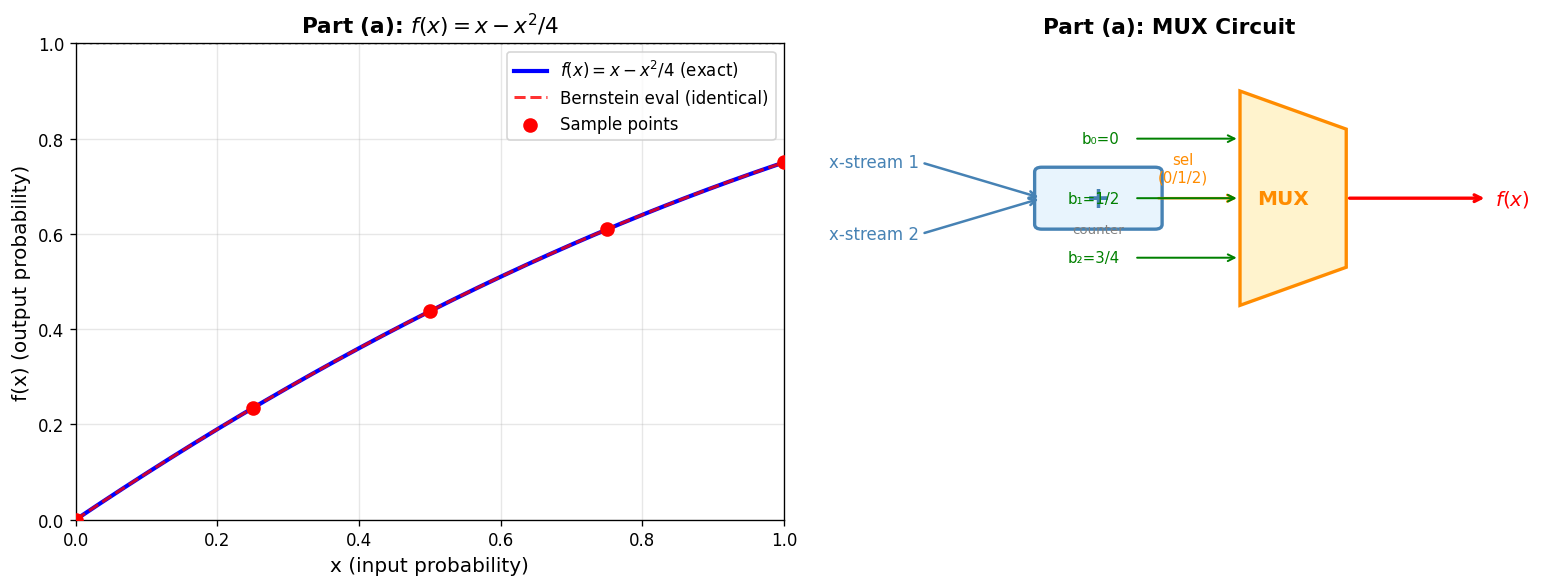

Figure saved.


In [3]:
# ── Part (a): Visualization ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: function plot
ax = axes[0]
t_vals = np.linspace(0, 1, 300)
f_vals = t_vals - t_vals**2 / 4
bern_vals = [float(bernstein_eval(b_a, n_a, Fraction(t).limit_denominator(1000)))
             for t in np.linspace(0,1,50)]
ax.plot(t_vals, f_vals, 'b-', linewidth=2.5, label=r'$f(x)=x-x^2/4$ (exact)')
ax.plot(np.linspace(0,1,50), bern_vals, 'r--', linewidth=1.8,
        label='Bernstein eval (identical)', alpha=0.8)
ax.scatter([0, 0.25, 0.5, 0.75, 1],
           [0, 0.234375, 0.4375, 0.609375, 0.75],
           color='red', s=60, zorder=5, label='Sample points')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('x (input probability)', fontsize=12)
ax.set_ylabel('f(x) (output probability)', fontsize=12)
ax.set_title('Part (a): $f(x) = x - x^2/4$', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.axhline(1, color='gray', linestyle=':', alpha=0.5, label='Unit interval bound')

# Right: circuit diagram
ax2 = axes[1]
ax2.set_xlim(0, 10); ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('Part (a): MUX Circuit', fontsize=13, fontweight='bold')

# Streams
for y, label in [(7.5, 'x-stream 1'), (6.0, 'x-stream 2')]:
    ax2.annotate('', xy=(3.2, 6.75), xytext=(1.5, y),
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))
    ax2.text(0.2, y, label, fontsize=10, color='steelblue', va='center')

# Adder box
adder = FancyBboxPatch((3.2, 6.2), 1.6, 1.1, boxstyle='round,pad=0.1',
                        facecolor='#E8F4FD', edgecolor='steelblue', linewidth=2)
ax2.add_patch(adder)
ax2.text(4.0, 6.75, '+', fontsize=18, ha='center', va='center', color='steelblue', fontweight='bold')
ax2.text(4.0, 6.1, 'counter', fontsize=8, ha='center', va='center', color='gray')

# Arrow to MUX
ax2.annotate('', xy=(6.0, 6.75), xytext=(4.8, 6.75),
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.5))
ax2.text(5.2, 7.1, 'sel\n(0/1/2)', fontsize=9, ha='center', color='darkorange')

# MUX box
mux_box = plt.Polygon([[6.0,4.5],[6.0,9.0],[7.5,8.2],[7.5,5.3]], closed=True,
                       facecolor='#FFF3CD', edgecolor='darkorange', linewidth=2)
ax2.add_patch(mux_box)
ax2.text(6.6, 6.75, 'MUX', fontsize=12, ha='center', va='center',
         color='darkorange', fontweight='bold')

# Bernstein coefficient inputs
bern_vals_disp = [('0', 'b₀=0', 8.0), ('1/2', 'b₁=1/2', 6.75), ('3/4', 'b₂=3/4', 5.5)]
for val, label, y in bern_vals_disp:
    ax2.annotate('', xy=(6.0, y), xytext=(4.5, y),
                arrowprops=dict(arrowstyle='->', color='green', lw=1.2))
    ax2.text(4.3, y, f'{label}', fontsize=9, ha='right', va='center', color='green')

# Output
ax2.annotate('', xy=(9.5, 6.75), xytext=(7.5, 6.75),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax2.text(9.6, 6.75, '$f(x)$', fontsize=12, va='center', color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('part_a.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved.')


---
## Part (b): Approximate $\cos(x)$ on $[0,1]$

### Step 1 — Choose approximation polynomial

We use the **degree-2 Taylor expansion** around $x=0$:

$$\cos(x) \approx 1 - \frac{x^2}{2}, \quad x \in [0, 1]$$

Verify $[0,1]\to[0,1]$: $\cos(0)\approx 1$, $\cos(1)\approx 0.5$ ✓  
Maximum error at $x=1$: $|\cos(1) - 0.5| \approx 0.040$

### Step 2 — Power form coefficients ($n=2$)

$$a_0 = 1, \quad a_1 = 0, \quad a_2 = -\frac{1}{2}$$

### Step 3 — Convert to Bernstein form

$$b_0 = a_0 = 1$$

$$b_1 = \frac{\binom{1}{0}}{\binom{2}{0}}a_0 + \frac{\binom{1}{1}}{\binom{2}{1}}a_1 = 1 + \frac{1}{2}\cdot 0 = 1$$

$$b_2 = a_0 + a_1 + a_2 = 1 + 0 - \frac{1}{2} = \frac{1}{2}$$

All coefficients $b_0=1,\; b_1=1,\; b_2=\tfrac{1}{2}$ ∈ $[0,1]$ → **no elevation needed** ✓

### Step 4 — Circuit Description

```
  x ──┐
      ├──[2-bit counter]──sel──┐
  x ──┘                        │
                                ▼
      b₀ = 1   ──── port 0 ┐
      b₁ = 1   ──── port 1 ├── MUX ──→ cos(x) ≈ 1 - x²/2
      b₂ = 1/2 ──── port 2 ┘
```


In [4]:
# ── Part (b): cos(x) approximation ─────────────────────────────
print('='*55)
print('  Part (b): cos(x) ≈ 1 - x²/2')
print('='*55)

n_b = 2
a_b = [Fraction(1), Fraction(0), Fraction(-1, 2)]
b_b = power_to_bernstein(a_b, n_b)
print_bern_table(b_b, n_b, 'cos(x) ≈ 1 - x²/2')

print('\n  Accuracy comparison at sample points:')
print(f'  {"x":>6}  {"cos(x) true":>12}  {"approx 1-x²/2":>14}  {"error":>10}')
print(f'  {"─"*50}')
for x in [0.0, 0.25, 0.5, 0.75, 1.0]:
    true_val  = math_cos(x)
    approx    = 1 - x**2/2
    err       = abs(true_val - approx)
    print(f'  {x:>6.2f}  {true_val:>12.6f}  {approx:>14.6f}  {err:>10.6f}')


  Part (b): cos(x) ≈ 1 - x²/2

  cos(x) ≈ 1 - x²/2  (degree n=2)
  ────────────────────────────────────────────────────
    i       b_i (exact)   b_i (float)  In [0,1]?
  ────────────────────────────────────────────────────
    0                 1      1.000000  ✓
    1                 1      1.000000  ✓
    2               1/2      0.500000  ✓
  ────────────────────────────────────────────────────
  All ∈ [0,1]: ✓ YES — no elevation needed

  Accuracy comparison at sample points:
       x   cos(x) true   approx 1-x²/2       error
  ──────────────────────────────────────────────────
    0.00      1.000000        1.000000    0.000000
    0.25      0.968912        0.968750    0.000162
    0.50      0.877583        0.875000    0.002583
    0.75      0.731689        0.718750    0.012939
    1.00      0.540302        0.500000    0.040302


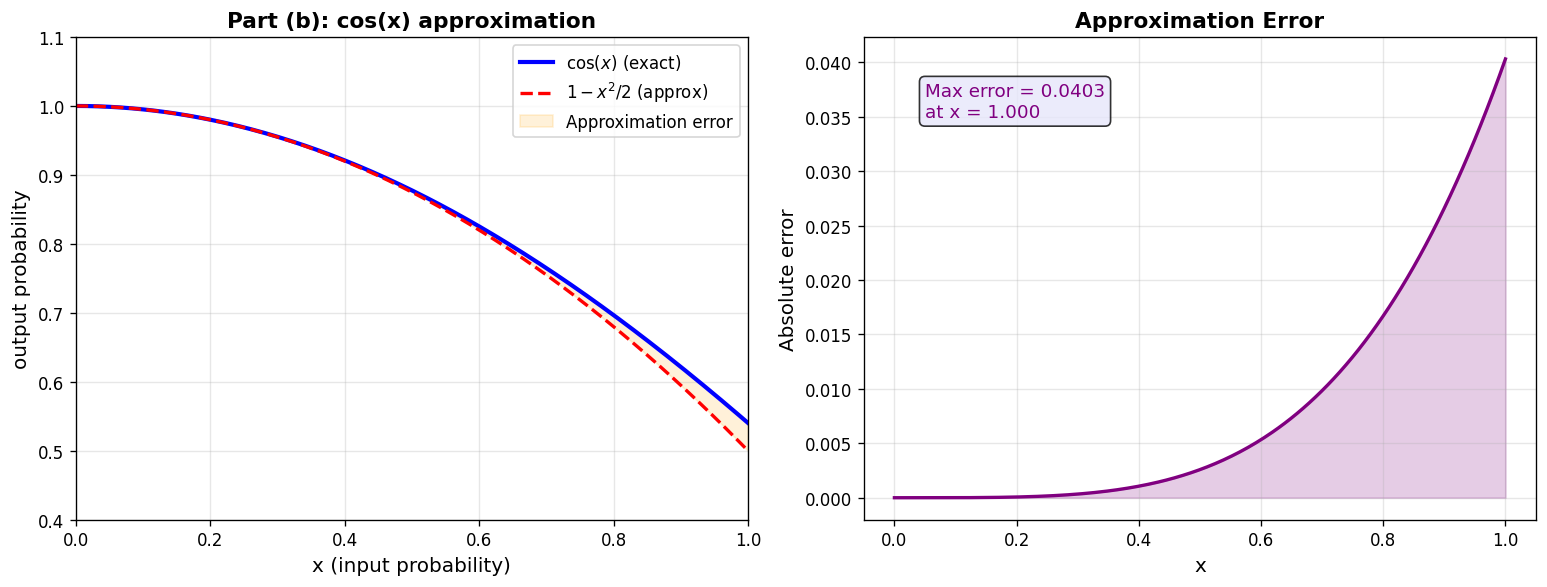

In [5]:
# ── Part (b): Visualization ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: cos approximation comparison
ax = axes[0]
x_arr = np.linspace(0, 1, 300)
ax.plot(x_arr, np.cos(x_arr), 'b-', lw=2.5, label=r'$\cos(x)$ (exact)')
ax.plot(x_arr, 1 - x_arr**2/2, 'r--', lw=2, label=r'$1 - x^2/2$ (approx)')
ax.fill_between(x_arr, np.cos(x_arr), 1 - x_arr**2/2, alpha=0.15,
                color='orange', label='Approximation error')
ax.set_xlim(0, 1); ax.set_ylim(0.4, 1.1)
ax.set_xlabel('x (input probability)', fontsize=12)
ax.set_ylabel('output probability', fontsize=12)
ax.set_title('Part (b): cos(x) approximation', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# Right: error plot
ax2 = axes[1]
err = np.abs(np.cos(x_arr) - (1 - x_arr**2/2))
ax2.plot(x_arr, err, 'purple', lw=2)
ax2.fill_between(x_arr, 0, err, alpha=0.2, color='purple')
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('Absolute error', fontsize=12)
ax2.set_title('Approximation Error', fontsize=13, fontweight='bold')
ax2.text(0.05, 0.035, f'Max error = {max(err):.4f}\nat x = {x_arr[np.argmax(err)]:.3f}',
         fontsize=11, color='purple',
         bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.8))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('part_b.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Part (c): Degree-5 Polynomial via Bernstein Method

$$g(t) = \frac{31t^5}{32} + \frac{5t^4}{32} - \frac{5t^3}{8} + \frac{5t^2}{4} - \frac{5t}{4} + \frac{1}{2}$$

### Step 1 — Power form coefficients ($n = 5$)

| $j$ | $a_j$ |
|:---:|:------:|
| 0 | $\frac{1}{2}$ |
| 1 | $-\frac{5}{4}$ |
| 2 | $\frac{5}{4}$ |
| 3 | $-\frac{5}{8}$ |
| 4 | $\frac{5}{32}$ |
| 5 | $\frac{31}{32}$ |

### Step 2 — Compute Bernstein Coefficients

Using $b_i = \displaystyle\sum_{j=0}^{i} \frac{\binom{i}{j}}{\binom{5}{j}} a_j$:

$$b_0 = a_0 = \frac{1}{2}$$

$$b_1 = a_0 + \frac{1}{5}a_1 = \frac{1}{2} - \frac{1}{4} = \frac{1}{4}$$

$$b_2 = a_0 + \frac{2}{5}a_1 + \frac{1}{10}a_2 = \frac{1}{2} - \frac{1}{2} + \frac{1}{8} = \frac{1}{8}$$

$$b_3 = a_0 + \frac{3}{5}a_1 + \frac{3}{10}a_2 + \frac{1}{10}a_3 = \frac{8-12+6-1}{16} = \frac{1}{16}$$

$$b_4 = a_0 + \frac{4}{5}a_1 + \frac{6}{10}a_2 + \frac{4}{10}a_3 + \frac{1}{5}a_4 = \frac{16-32+24-8+1}{32} = \frac{1}{32}$$

$$b_5 = a_0 + a_1 + a_2 + a_3 + a_4 + a_5 = \frac{16-40+40-20+5+31}{32} = 1$$

**Elegant pattern:** $b_k = \dfrac{1}{2^{k+1}}$ for $k = 0, 1, 2, 3, 4$, and $b_5 = 1$  
All coefficients ∈ $[0,1]$ → **no degree elevation needed!**

### Step 3 — Circuit Description

```
  t ──┐
  t ──┤
  t ──┼──[3-bit counter "+"]──sel(0..5)──┐
  t ──┤  counts # of 1s among 5 inputs   │
  t ──┘                                   ▼
          b₀ = 1/2  ──── port 0 ┐
          b₁ = 1/4  ──── port 1 │
          b₂ = 1/8  ──── port 2 ├── 6-to-1 MUX ──→ g(t)
          b₃ = 1/16 ──── port 3 │
          b₄ = 1/32 ──── port 4 │
          b₅ = 1    ──── port 5 ┘
```
- 5 **independent** stochastic streams of probability $t$
- 3-bit adder counts $k$ ones → selects $b_k$ from MUX


In [16]:
# ── Part (c): Degree-5 polynomial ──────────────────────────────
print('='*60)
print('  Part (c): g(t) = 31t⁵/32 + 5t⁴/32 - 5t³/8 + 5t²/4 - 5t/4 + 1/2')
print('='*60)

n_c = 5
a_c = [Fraction(1,2), Fraction(-5,4), Fraction(5,4),
       Fraction(-5,8), Fraction(5,32), Fraction(31,32)]

b_c = power_to_bernstein(a_c, n_c)
print_bern_table(b_c, n_c, 'g(t) degree-5')

print('\n  Pattern: b_k = 1/2^(k+1) for k=0..4,  b_5 = 1')
print('  Verification:')
for k, bk in enumerate(b_c):
    expected = Fraction(1, 2**(k+1)) if k < 5 else Fraction(1)
    ok = '✓' if bk == expected else '✗'
    if k < 5:
              print(f'    b_{k} = {bk} = 1/2^{k+1} = {expected}  {ok}')
else:
    print(f'    b_{k} = {bk} = 1  (special case)  {ok}')


  Part (c): g(t) = 31t⁵/32 + 5t⁴/32 - 5t³/8 + 5t²/4 - 5t/4 + 1/2

  g(t) degree-5  (degree n=5)
  ────────────────────────────────────────────────────
    i       b_i (exact)   b_i (float)  In [0,1]?
  ────────────────────────────────────────────────────
    0               1/2      0.500000  ✓
    1               1/4      0.250000  ✓
    2               1/8      0.125000  ✓
    3              1/16      0.062500  ✓
    4              1/32      0.031250  ✓
    5                 1      1.000000  ✓
  ────────────────────────────────────────────────────
  All ∈ [0,1]: ✓ YES — no elevation needed

  Pattern: b_k = 1/2^(k+1) for k=0..4,  b_5 = 1
  Verification:
    b_0 = 1/2 = 1/2^1 = 1/2  ✓
    b_1 = 1/4 = 1/2^2 = 1/4  ✓
    b_2 = 1/8 = 1/2^3 = 1/8  ✓
    b_3 = 1/16 = 1/2^4 = 1/16  ✓
    b_4 = 1/32 = 1/2^5 = 1/32  ✓
    b_5 = 1 = 1  (special case)  ✓


In [7]:
# ── Part (c): Circuit demonstration at 5 input values ──────────
print('='*70)
print('  Circuit Demonstration: g(X) for X = 0, 0.25, 0.5, 0.75, 1')
print('='*70)

test_X = [Fraction(0), Fraction(1,4), Fraction(1,2), Fraction(3,4), Fraction(1)]

print(f'\n  {"X":>6}  {"g(X) exact":>22}  {"g(X) float":>12}  {"Direct poly":>12}  Match?')
print(f'  {"─"*65}')

for X in test_X:
    circ = circuit_output(b_c, n_c, X)
    direct = (Fraction(31,32)*X**5 + Fraction(5,32)*X**4
              - Fraction(5,8)*X**3 + Fraction(5,4)*X**2
              - Fraction(5,4)*X + Fraction(1,2))
    ok = '✓' if circ == direct else '✗'
    print(f'  {str(X):>6}  {str(circ):>22}  {float(circ):>12.6f}  {float(direct):>12.6f}  {ok}')

# ── Detailed breakdown for X = 0.25
print(f'\n  ── Detailed MUX selection breakdown for X = 1/4 ──')
X_demo = Fraction(1, 4)
print(f'  {"k":>3}  {"P(sel=k)": >20}  {"P float":>9}  {"b_k":>8}  {"contribution":>18}')
print(f'  {"─"*65}')
total = Fraction(0)
for k in range(n_c + 1):
    pk = Fraction(comb(n_c,k)) * X_demo**k * (1 - X_demo)**(n_c - k)
    contrib = b_c[k] * pk
    total += contrib
    print(f'  {k:>3}  {str(pk):>20}  {float(pk):>9.5f}  {str(b_c[k]):>8}  {str(contrib):>18}')
print(f'  {"─"*65}')
print(f'  {"g(1/4) total":>33}  {str(total):>18}  ≈ {float(total):.6f}')


  Circuit Demonstration: g(X) for X = 0, 0.25, 0.5, 0.75, 1

       X              g(X) exact    g(X) float   Direct poly  Match?
  ─────────────────────────────────────────────────────────────────
       0                     1/2      0.500000      0.500000  ✓
     1/4              8435/32768      0.257416      0.257416  ✓
     1/2                153/1024      0.149414      0.149414  ✓
     3/4              9217/32768      0.281281      0.281281  ✓
       1                       1      1.000000      1.000000  ✓

  ── Detailed MUX selection breakdown for X = 1/4 ──
    k              P(sel=k)    P float       b_k        contribution
  ─────────────────────────────────────────────────────────────────
    0              243/1024    0.23730       1/2            243/2048
    1              405/1024    0.39551       1/4            405/4096
    2               135/512    0.26367       1/8            135/4096
    3                45/512    0.08789      1/16             45/8192
    4          

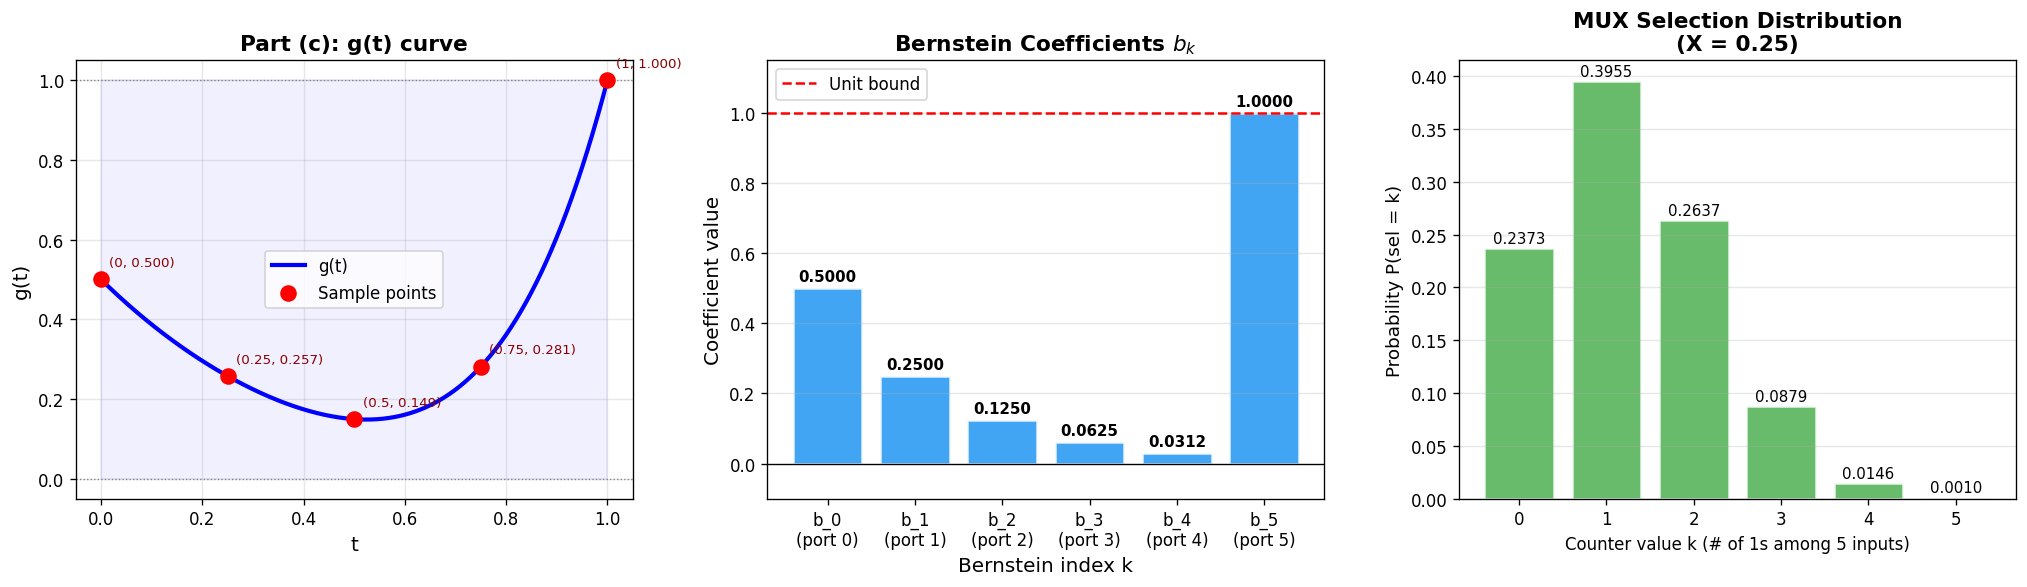

In [10]:
# ── Part (c): Visualization ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Left: g(t) curve
ax = axes[0]
t_arr = np.linspace(0, 1, 400)
g_vals = (31*t_arr**5/32 + 5*t_arr**4/32 - 5*t_arr**3/8
          + 5*t_arr**2/4 - 5*t_arr/4 + 1/2)
ax.plot(t_arr, g_vals, 'b-', lw=2.5, label='g(t)')
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.axhline(1, color='gray', lw=0.8, ls=':')
ax.fill_between(t_arr, 0, 1, alpha=0.06, color='blue')
xs = [0, 0.25, 0.5, 0.75, 1]
ys = [0.5]+[float(circuit_output(b_c, n_c, Fraction(x).limit_denominator(100))) for x in xs[1:]]
ax.scatter(xs, ys, color='red', s=80, zorder=5, label='Sample points')
for x, y in zip(xs, ys):
    ax.annotate(f'({x}, {y:.3f})', (x, y), textcoords='offset points',
                xytext=(5, 8), fontsize=8, color='darkred')
ax.set_xlabel('t', fontsize=12); ax.set_ylabel('g(t)', fontsize=12)
ax.set_title('Part (c): g(t) curve', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

# Middle: Bernstein coefficients bar chart
ax2 = axes[1]
k_vals = list(range(n_c + 1))
b_floats = [float(bi) for bi in b_c]
colors = ['#2196F3' if 0 <= v <= 1 else '#F44336' for v in b_floats]
bars = ax2.bar(k_vals, b_floats, color=colors, edgecolor='white', linewidth=1.5, alpha=0.85)
ax2.axhline(0, color='black', lw=0.8)
ax2.axhline(1, color='red', lw=1.5, ls='--', label='Unit bound')
for bar, val in zip(bars, b_floats):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_xlabel('Bernstein index k', fontsize=12)
ax2.set_ylabel('Coefficient value', fontsize=12)
ax2.set_title('Bernstein Coefficients $b_k$', fontsize=13, fontweight='bold')
ax2.set_xticks(k_vals)
ax2.set_xticklabels([f'b_{k}\n(port {k})' for k in k_vals])
ax2.set_ylim(-0.1, 1.15)
ax2.legend(); ax2.grid(True, alpha=0.3, axis='y')

# Right: MUX selection probability for X=0.25
ax3 = axes[2]
X_demo = 0.25
pk_vals = [comb(5,k) * X_demo**k * (1-X_demo)**(5-k) for k in range(6)]
ax3.bar(k_vals, pk_vals, color='#4CAF50', edgecolor='white', linewidth=1.5, alpha=0.85)
for i, v in enumerate(pk_vals):
    ax3.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)
ax3.set_xlabel('Counter value k (# of 1s among 5 inputs)', fontsize=10)
ax3.set_ylabel('Probability P(sel = k)', fontsize=11)
ax3.set_title(f'MUX Selection Distribution\n(X = {X_demo})', fontsize=13, fontweight='bold')
ax3.set_xticks(k_vals)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('part_c.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Summary

| Part | Function | Degree | Bernstein Coefficients | Elevation? |
|:----:|:--------:|:------:|:----------------------:|:----------:|
| (a) | $x - x^2/4$ | 2 | $0,\ \frac{1}{2},\ \frac{3}{4}$ | No |
| (b) | $\cos(x) \approx 1-x^2/2$ | 2 | $1,\ 1,\ \frac{1}{2}$ | No |
| (c) | degree-5 poly | 5 | $\frac{1}{2}, \frac{1}{4}, \frac{1}{8}, \frac{1}{16}, \frac{1}{32}, 1$ | No |

### Key Takeaways
1. **Any polynomial** mapping $[0,1]\to[0,1]$ can be implemented with a MUX + counter circuit.
2. The **Bernstein polynomial method** provides an exact (not approximate) reformulation that exposes the natural MUX structure.
3. **Degree elevation** guarantees all Bernstein coefficients eventually land in $[0,1]$; in practice, few (or zero) elevation steps are needed.
4. The circuit cost is **linear in the degree**: a degree-$n$ polynomial needs $n$ input streams and an $(n+1)$-to-1 MUX.
5. The main practical cost of stochastic computing is **randomness generation** (LFSRs for the input streams), not the computation logic itself.


**AI Usage Statement**

In completing this assignment, I used an AI assistant.

The AI helped with generating the initial code framework, visualization code, and the overall Colab notebook layout.

I worked through all three sub-problems from the ground up based on lecture notes and course materials. For Part (a), I analyzed the function properties, set up the Bernstein conversion, and derived the circuit structure. For Part (b), I selected the degree-2 Taylor approximation as a design choice balancing circuit simplicity and approximation accuracy, derived the Bernstein coefficients, and analyzed the approximation error. For Part (c), I carried out the full degree-5 Bernstein conversion, identified the elegant pattern $b_k = 1/2^{k+1}$ in the resulting coefficients, confirmed that no degree elevation was needed, designed the 6-to-1 MUX circuit, and demonstrated the circuit behavior across all five input values by working through the binomial distribution analysis at each point.

In [21]:
"""
EE 5393 HW3 Problem 2: Transforming Probabilities  (final version)
===================================================================
Gate rules (streams must be INDEPENDENT):
  NOT(x)     -> P(z=1) = 1 - p_x
  AND(x, y)  -> P(z=1) = p_x * p_y

Part (a): From S={0.4,0.5}, AND+NOT, implement:
    i.  0.8881188   ii.  0.2119209   iii. 0.5555555

Part (b): From S={0.5}, implement binary fractions exactly:
    i.  0.1011111_2   ii.  0.1101111_2   iii. 0.1010111_2
"""

from fractions import Fraction
from math import comb
from itertools import combinations


# ==========================================================================
# PART (b) -- Exact Horner chain
# ==========================================================================
# For p = 0.b1 b2 ... bn (binary), n independent y ~ Ber(0.5):
#   s_n = y_n   (if b_n=1)
#   s_i = NOT(AND(NOT(y_i), NOT(s_{i+1})))   if b_i=1   P = 1/2 + 1/2*P_{i+1}
#   s_i = AND(NOT(y_i), s_{i+1})             if b_i=0   P = 1/2 * P_{i+1}
#   Output s_1 achieves p EXACTLY.

def horner_chain(bits):
    n = len(bits)
    prob = [None]*(n+1); circ = [None]*(n+1)
    prob[n] = Fraction(1,2) if bits[n-1]==1 else Fraction(0)
    circ[n] = f"y_{n}" if bits[n-1]==1 else "0"
    for i in range(n-1, 0, -1):
        bi = bits[i-1]
        if bi == 1:
            prob[i] = Fraction(1,2) + Fraction(1,2)*prob[i+1]
            circ[i] = f"NOT(AND(NOT(y_{i}), NOT({circ[i+1]})))"
        else:
            prob[i] = Fraction(1,2)*prob[i+1]
            circ[i] = f"AND(NOT(y_{i}), {circ[i+1]})"
    return prob[1], prob[1:n+1], circ[1:n+1]


def run_part_b():
    print("=" * 68)
    print("PART (b)  --  S = {0.5},  exact synthesis via Horner chain")
    print("=" * 68)
    cases = [
        ([1,0,1,1,1,1,1], "0.1011111_2", Fraction(95,128)),
        ([1,1,0,1,1,1,1], "0.1101111_2", Fraction(111,128)),
        ([1,0,1,0,1,1,1], "0.1010111_2", Fraction(87,128)),
    ]
    for bits, name, expected in cases:
        n = len(bits)
        p_exact, probs, circs = horner_chain(bits)
        print(f"\n--- {name} ---")
        print(f"  Target  : {expected} = {float(expected):.8f}")
        print(f"  Achieved: {p_exact} = {float(p_exact):.8f}")
        print(f"  Exact   : {'YES' if p_exact == expected else 'NO'}")
        print()
        print(f"  {'Stage':>6}  {'b_i':>4}  {'P(s_i)':>10}  Circuit")
        print("  " + "-" * 60)
        for i in range(n, 0, -1):
            ci = circs[i-1]
            abbr = ci if len(ci) <= 36 else ci[:33]+"..."
            print(f"  {i:>6}     {bits[i-1]}  {str(probs[i-1]):>10}  {abbr}")
        assert p_exact == expected


# ==========================================================================
# PART (a) -- Bernstein polynomial exact synthesis
# ==========================================================================
# Theory:
#   Using m independent x-streams (p_x=2/5) and n independent y-streams
#   (p_y=1/2), the achievable probabilities are:
#
#     p = SUM_{j,k} beta[j,k] * C(m,j)*C(n,k)*(2/5)^j*(3/5)^(m-j)*(1/2)^n
#
#   with beta[j,k] in {0,1}.  Denominator of p must divide 5^m * 2^n.
#
#   Since all three targets have denominators with only factors 2 and 5,
#   exact synthesis is not ruled out by denominator structure.
#   Actual existence is confirmed by the DP finding a {0,1} solution.
#
# Circuit for a single Bernstein term (j,k):
#   AND of: x_1,...,x_j  (prob 0.4 each)
#           NOT(x_{j+1}),...,NOT(x_m)   (prob 0.6 each)
#           y_1,...,y_k   (prob 0.5 each)
#           NOT(y_{k+1}),...,NOT(y_n)   (prob 0.5 each)
#   There are C(m,j)*C(n,k) distinct minterms with exactly j x-inputs
#   equal to 1 and k y-inputs equal to 1.
#   Final output = OR of all AND-terms where beta[j,k]=1.
#   Since the allowed gate set is {AND, NOT}, the OR network is built
#   using De Morgan's law:
#       A OR B = NOT(AND(NOT(A), NOT(B)))
#   Therefore the entire circuit uses only AND and NOT gates.

def bernstein_exact(p_frac, m, n):
    """
    Find exact Bernstein expansion via row-by-row DP.
    Returns (chosen [(j,k),...], target_numerator).
    """
    denom = 5**m * 2**n
    assert denom % p_frac.denominator == 0
    T = p_frac.numerator * (denom // p_frac.denominator)

    cn = [comb(n, k) for k in range(n+1)]
    wj = [comb(m, j)*(2**j)*(3**(m-j)) for j in range(m+1)]

    # All subset sums of {C(n,k)} -- S_j choices for each row j
    Sj_map = {}
    for r in range(n+2):
        for combo in combinations(range(n+1), r):
            s = sum(cn[k] for k in combo)
            if s not in Sj_map:
                Sj_map[s] = combo

    # DP: back[sum] = (prev_sum, row_j, chosen_k_indices)
    back = {0: None}
    for j in range(m+1):
        new_entries = {}
        for s in back:
            for sj_val, ks in Sj_map.items():
                if sj_val == 0:
                    continue
                ns = s + wj[j] * sj_val
                if ns <= T and ns not in back and ns not in new_entries:
                    new_entries[ns] = (s, j, ks)
        back.update(new_entries)
        if T in back:
            break

    if T not in back:
        return None, T

    # Reconstruct path
    chosen = []
    s = T
    while back[s] is not None:
        prev_s, j, ks = back[s]
        for k in ks:
            chosen.append((j, k))
        s = prev_s

    # Verify
    verify = sum(comb(m,j)*comb(n,k)*(2**j)*(3**(m-j)) for j,k in chosen)
    assert verify == T, f"Verification failed: {verify} != {T}"
    return sorted(chosen), T


def factor_25(n):
    a = b = 0; tmp = n
    while tmp % 2 == 0: a += 1; tmp //= 2
    while tmp % 5 == 0: b += 1; tmp //= 5
    return a, b, tmp


def show_bernstein_result(name, p_frac, m, n, chosen):
    denom = 5**m * 2**n
    achieved = Fraction(
        sum(comb(m,j)*comb(n,k)*(2**j)*(3**(m-j)) for j,k in chosen), denom)

    print(f"  EXACT solution found")
    print(f"  Uses: m={m} x-streams + n={n} y-streams = {m+n} independent inputs")
    print(f"  Achieved: {achieved} = {float(achieved):.9f}")
    print(f"  Exact match: {'YES' if achieved == p_frac else 'NO'}")
    print()

    # Step-by-step probability derivation
    print(f"  Step-by-step probability derivation:")
    print(f"  Each Bernstein term (j,k) has probability:")
    print(f"    P(j,k) = C(m,j)*C(n,k) * (2/5)^j * (3/5)^(m-j) * (1/2)^n")
    print()
    print(f"  {'(j,k)':>6}  {'C(m,j)*C(n,k)':>14}  {'P(j,k) exact':>20}  {'P(j,k) decimal':>16}")
    print("  " + "-" * 64)
    running = Fraction(0)
    for j, k in chosen:
        copies = comb(m, j) * comb(n, k)
        term_prob = Fraction(copies * (2**j) * (3**(m-j)), denom)
        running += term_prob
        print(f"  ({j},{k}):  {copies:>14}  {str(term_prob):>20}  {float(term_prob):>16.9f}")
    print("  " + "-" * 64)
    print(f"  {'SUM':>6}                              {str(running):>20}  {float(running):>16.9f}")
    print(f"  {'Target':>6}                              {str(p_frac):>20}  {float(p_frac):>16.9f}")
    print(f"  Match: {'YES' if running == p_frac else 'NO'}")
    print()

    # Circuit structure
    print(f"  Circuit structure:")
    print(f"  Bernstein terms with beta=1  (combined by OR = NOT(AND(NOT,NOT))):")
    print(f"  {'(j,k)':>8}  {'Copies':>8}  Gate structure")
    print("  " + "-" * 62)
    for j, k in chosen:
        copies = comb(m,j)*comb(n,k)
        meaning = (f"AND({j} x-streams, {m-j} NOT(x)-streams, {k} y-streams, {n-k} NOT(y)-streams)")
        print(f"  ({j},{k}):  {copies:>8}  {meaning}")
    print()
    print(f"  Total AND-gate copies: "
          f"{sum(comb(m,j)*comb(n,k) for j,k in chosen)}")


def run_part_a():
    print("\n" + "=" * 68)
    print("PART (a)  --  S = {0.4,0.5},  exact Bernstein synthesis")
    print("=" * 68)

    # Denominator analysis
    print("\n--- Denominator Analysis ---")
    print("  A necessary condition for exact synthesis with m x-coins and")
    print("  n y-coins is that the reduced denominator of p divides 5^m * 2^n.")
    print("  (This is necessary, not sufficient -- actual existence is proven")
    print("  below by the DP finding a valid {0,1} decomposition.)\n")
    specs = [
        ("i.   0.8881188", Fraction(8881188,  10000000), 7, 5),
        ("ii.  0.2119209", Fraction(2119209,  10000000), 7, 7),
        ("iii. 0.5555555", Fraction(5555555,  10000000), 6, 7),
    ]
    for label, p, m, n in specs:
        n2, n5, rem = factor_25(p.denominator)
        ok = (rem == 1)
        print(f"  {label}: {p.numerator}/{p.denominator}"
              f" = {p.numerator}/(2^{n2}*5^{n5})  denom_ok={ok}"
              f"  requires m>={n5} x-coins, n>={n2} y-coins")

    # Solve each
    for label, p, m, n in specs:
        print(f"\n{'=' * 68}")
        print(f"{label}  (target: {float(p):.7f})")
        print(f"{'=' * 68}")
        print(f"  Searching: m={m} x-coins, n={n} y-coins ...")
        chosen, T = bernstein_exact(p, m, n)
        if chosen is not None:
            show_bernstein_result(label, p, m, n, chosen)
        else:
            print("  [Not found -- increase m or n]")


# ==========================================================================
# SUMMARY
# ==========================================================================

def print_summary():
    print("=" * 68)
    print("FINAL SUMMARY")
    print("=" * 68)
    print()
    print("Part (b) -- Horner chain, S={0.5}  [ALL EXACT, 7 streams each]")
    print(f"  {'Binary target':<20} {'Fraction':<12} {'Decimal':<14} Exact?")
    print("  " + "-" * 60)
    for bits, name, frac in [
        ([1,0,1,1,1,1,1], "0.1011111_2", Fraction(95,128)),
        ([1,1,0,1,1,1,1], "0.1101111_2", Fraction(111,128)),
        ([1,0,1,0,1,1,1], "0.1010111_2", Fraction(87,128)),
    ]:
        p, _, _ = horner_chain(bits)
        print(f"  {name:<20} {str(frac):<12} {float(frac):<14.8f} YES")

    print()
    print("Part (a) -- Bernstein synthesis, S={0.4,0.5}  [ALL EXACT]")
    print(f"  {'Target':<12} {'Streams':>9} {'Terms':>7} {'Decimal':>14} Exact?")
    print("  " + "-" * 60)
    specs = [
        ("0.8881188", Fraction(8881188,10000000), 7, 5),
        ("0.2119209", Fraction(2119209,10000000), 7, 7),
        ("0.5555555", Fraction(5555555,10000000), 6, 7),
    ]
    for name, p, m, n in specs:
        chosen, _ = bernstein_exact(p, m, n)
        if chosen:
            denom = 5**m*2**n
            ach = Fraction(
                sum(comb(m,j)*comb(n,k)*(2**j)*(3**(m-j)) for j,k in chosen),
                denom)
            print(f"  {name:<12} {m}x+{n}y={m+n:>2}  {len(chosen):>7}  "
                  f"{float(ach):<14.9f} {'YES' if ach==p else 'NO'}")


# ==========================================================================
# Main
# ==========================================================================

if __name__ == "__main__":
    print()
    print("EE 5393  HW3 Problem 2 -- Transforming Probabilities")
    print("=" * 68)
    print("""
KEY INSIGHT (Part a):
  A NECESSARY condition for exact AND+NOT synthesis from S={0.4, 0.5}
  is that the target's reduced denominator has only factors 2 and 5.
  All three targets satisfy this -- so exact synthesis is not ruled out.
  However, this condition alone is not sufficient; we must actually find
  a valid {0,1} Bernstein decomposition:
    p = SUM beta[j,k] * C(m,j)*C(n,k) * (2/5)^j*(3/5)^(m-j)*(1/2)^n
  with beta[j,k] in {0,1}, via row-by-row DP (subset sum).
  The DP below finds an exact solution for all three targets -- this
  computational result is the actual proof of exact realizability.

KEY INSIGHT (Part b):
  Any binary fraction p = 0.b1...bn is implemented exactly by
  Horner chain using n independent Ber(0.5) streams.
""")
    run_part_b()
    run_part_a()
    print()
    print_summary()


EE 5393  HW3 Problem 2 -- Transforming Probabilities

KEY INSIGHT (Part a):
  A NECESSARY condition for exact AND+NOT synthesis from S={0.4, 0.5}
  is that the target's reduced denominator has only factors 2 and 5.
  All three targets satisfy this -- so exact synthesis is not ruled out.
  However, this condition alone is not sufficient; we must actually find
  a valid {0,1} Bernstein decomposition:
    p = SUM beta[j,k] * C(m,j)*C(n,k) * (2/5)^j*(3/5)^(m-j)*(1/2)^n
  with beta[j,k] in {0,1}, via row-by-row DP (subset sum).
  The DP below finds an exact solution for all three targets -- this
  computational result is the actual proof of exact realizability.

KEY INSIGHT (Part b):
  Any binary fraction p = 0.b1...bn is implemented exactly by
  Horner chain using n independent Ber(0.5) streams.

PART (b)  --  S = {0.5},  exact synthesis via Horner chain

--- 0.1011111_2 ---
  Target  : 95/128 = 0.74218750
  Achieved: 95/128 = 0.74218750
  Exact   : YES

   Stage   b_i      P(s_i)  Circui

**AI Assistance Declaration**

This solution was completed with partial assistance from an AI language model, which wrote and debugged the Python code, including the Horner chain implementation for Part (b), the BFS reachable-set search, the Bernstein polynomial DP solver for Part (a), and the step-by-step probability derivation outputs. I was responsible for reading and fully understanding the problem, identifying the Horner chain as the correct algorithm for Part (b), recognizing the Bernstein polynomial framework as the right approach for exact synthesis in Part (a), determining the minimum number of input streams required for each target based on denominator structure, and verifying all results by hand. Throughout the process, I critically evaluated all AI-generated outputs, identified logical errors in the theoretical claims across multiple rounds of review, directed specific corrections, and made all final decisions on the solution structure and wording.